# Проект 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import psycopg2
import warnings
warnings.filterwarnings('ignore')

In [2]:
user='student'
pasw='b5af9527fa'

conn = psycopg2.connect(
    host="92.63.70.133",
    port="5432",
    database="project",
    user=user,
    password=pasw
)

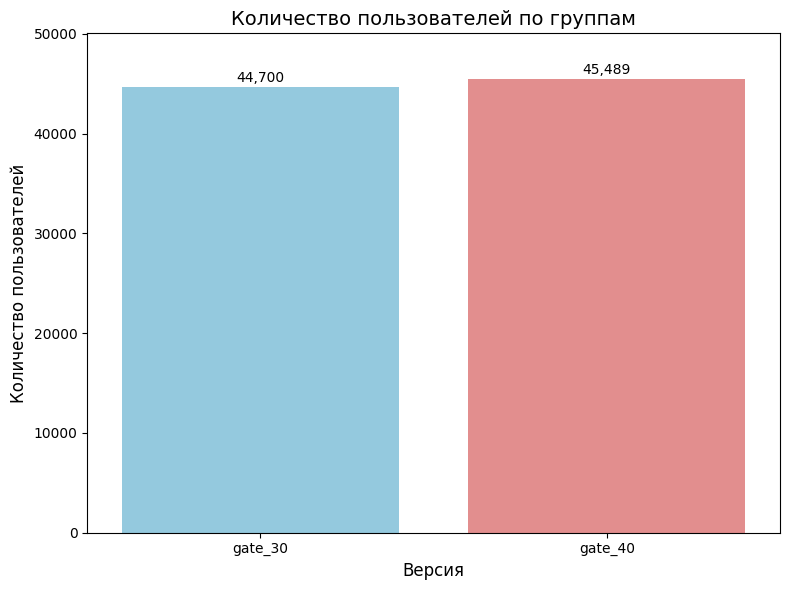

In [3]:
query = """
select 
version,
count(*) as count
from cookie_cats.ab_results
group by version
order by version

"""

df_groups = pd.read_sql(query, conn)

plt.figure(figsize=(8, 6))

sns.barplot(x='version', y='count', data=df_groups, palette=['skyblue', 'lightcoral'])

for index, row in df_groups.iterrows():
    plt.text(index, row['count'] + 500, f"{row['count']:,}", color='black', ha="center")

plt.title('Количество пользователей по группам', fontsize=14)
plt.xlabel('Версия', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.ylim(0, df_groups['count'].max() * 1.1)

plt.tight_layout() 
plt.show()

**Вывод:**  
А и Б выборка практически поделены 50 на 50, это правильно, самый лучший расклад для АБ тестирования. Всего пользователей 90189.

In [4]:
query = """
with aggregateddata as (
    select
        version,
        sum(case when sum_gamerounds is not null then 1 else 0 end) as users, 
        min(sum_gamerounds) as min_rounds,
        max(sum_gamerounds) as max_rounds,
        avg(sum_gamerounds) as mean_rounds,
        percentile_cont(0.5) within group (order by sum_gamerounds) as median_rounds,
        percentile_cont(0.75) within group (order by sum_gamerounds) as p75_rounds,
        percentile_cont(0.95) within group (order by sum_gamerounds) as p95_rounds,
        stddev(sum_gamerounds) as std_rounds
    from cookie_cats.ab_results
    group by version
)
select
    version,
    users,
    min_rounds,
    max_rounds,
    mean_rounds,
    median_rounds,
    p75_rounds,
    p95_rounds,
    std_rounds
from aggregateddata
order by version;
"""

df_stats = pd.read_sql(query, conn)
display(df_stats)

,version,users,min_rounds,max_rounds,mean_rounds,median_rounds,p75_rounds,p95_rounds,std_rounds
0,gate_30,44700,0,49854,52.456264,17.0,50.0,222.0,256.716423
1,gate_40,45489,0,2640,51.298776,16.0,52.0,220.0,103.294416


**Вывод:**  
По статистикам видно, что в каждой из групп есть те, кто не прошёл ни одного раунда, однако максимальное количество в контрольной выборке (30 уровень) на много больше, это может говорить, что там был игрок, который очень много играет, либо игрок который использовал читы на мгновенное прохождение.  
Среднее, медиана, 75 и 95 процентиль практически не отличаются, разница в единицах.  
А вот стандартное отклонение говорит о большем, видно, что в тесте (40 уровень) оно меньше, а значит количество пройденных раундов у большинства ближе к среднему значению, чем в контрольной выборке. 

,version,retention_1,retention_7,total_users,retained_1_count,retained_7_count
0,gate_30,0.45,0.19,44700,20034,8502
1,gate_40,0.44,0.18,45489,20119,8279


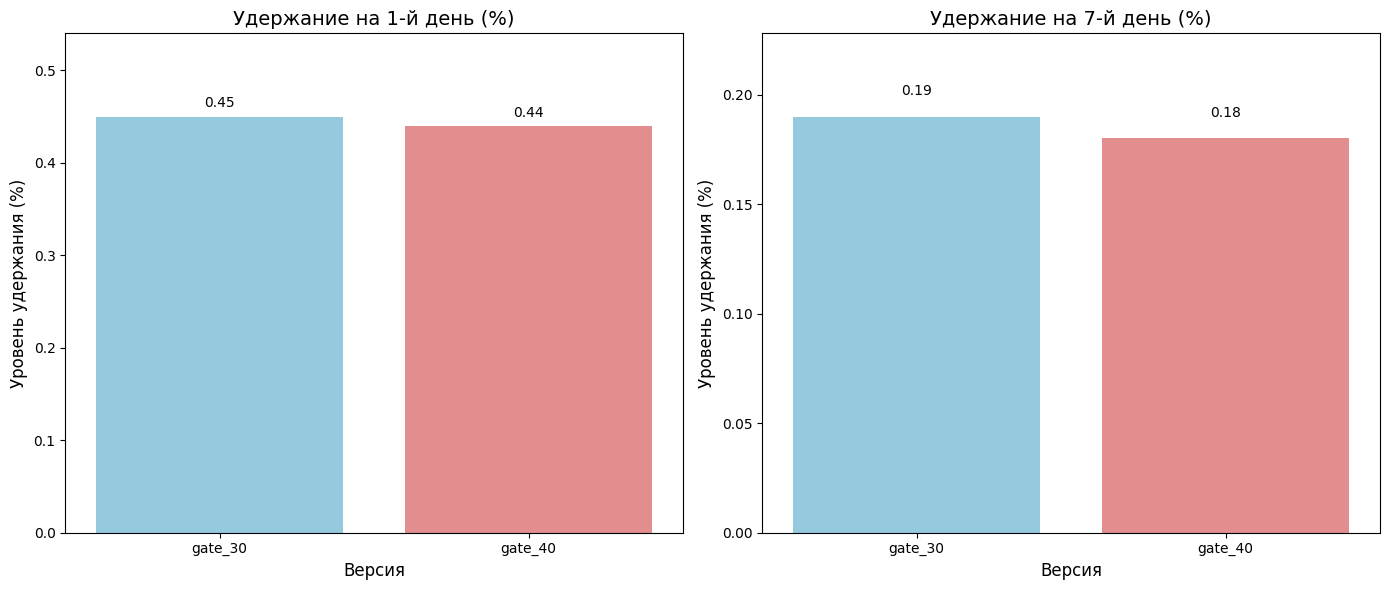

In [5]:
query = """
with playerdata as (
    select
        version,
        case when retention_1 = 'true' then 1 else 0 end as retention_1_int,
        case when retention_7 = 'true' then 1 else 0 end as retention_7_int
    from cookie_cats.ab_results
),
aggregateddata as (
    select
        version,
        avg(retention_1_int) as avg_retention_1,
        avg(retention_7_int) as avg_retention_7,
        count(*) as total_users,
        sum(retention_1_int) as retained_1_count,
        sum(retention_7_int) as retained_7_count
    from playerdata
    group by version
)
select
    version,
    round(avg_retention_1, 2) as retention_1,
    round(avg_retention_7, 2) as retention_7,
    total_users,
    retained_1_count,
    retained_7_count
from aggregateddata
order by version;
"""

df_retention = pd.read_sql(query, conn)
display(df_retention)

plt.figure(figsize=(14, 6)) 

plt.subplot(1, 2, 1) 
sns.barplot(x='version', y='retention_1', data=df_retention, palette=['skyblue', 'lightcoral'])

for index, row in df_retention.iterrows():
    plt.text(index, row['retention_1'] + 0.01, f"{row['retention_1']:.2f}", color='black', ha="center")

plt.title('Удержание на 1-й день (%)', fontsize=14)
plt.xlabel('Версия', fontsize=12)
plt.ylabel('Уровень удержания (%)', fontsize=12)
plt.ylim(0, df_retention['retention_1'].max() * 1.2) 

plt.subplot(1, 2, 2) 
sns.barplot(x='version', y='retention_7', data=df_retention, palette=['skyblue', 'lightcoral'])

for index, row in df_retention.iterrows():
    plt.text(index, row['retention_7'] + 0.01, f"{row['retention_7']:.2f}", color='black', ha="center")

plt.title('Удержание на 7-й день (%)', fontsize=14)
plt.xlabel('Версия', fontsize=12)
plt.ylabel('Уровень удержания (%)', fontsize=12)
plt.ylim(0, df_retention['retention_7'].max() * 1.2) 

plt.tight_layout() 
plt.show()

**Вывод:**  
Если смотреть удержание, то в контроле, оно немного больше и через 1 и через 7 дней.

In [6]:
query = """
with playerstats as (
    select
        version,
        count(*) as total_users,
        sum(case when sum_gamerounds >= 30 then 1 else 0 end) as reached_30_count,
        sum(case when sum_gamerounds >= 40 then 1 else 0 end) as reached_40_count,
        sum(case when sum_gamerounds >= 50 then 1 else 0 end) as reached_50_count,
        sum(case when sum_gamerounds >= 60 then 1 else 0 end) as reached_60_count,
        sum(case when sum_gamerounds >= 70 then 1 else 0 end) as reached_70_count
    from cookie_cats.ab_results
    group by version
)
select
    version,
    total_users,
    reached_30_count,
    reached_40_count,
    reached_50_count,
    reached_60_count,
    reached_70_count,
    round((reached_30_count * 100.0 / total_users), 2) as reached_30_percent,
    round((reached_40_count * 100.0 / total_users), 2) as reached_40_percent,
    round((reached_50_count * 100.0 / total_users), 2) as reached_50_percent,
    round((reached_60_count * 100.0 / total_users), 2) as reached_60_percent,
    round((reached_70_count * 100.0 / total_users), 2) as reached_70_percent
from playerstats
order by version;

"""

df_playerstats = pd.read_sql(query, conn)
display(df_playerstats)

,version,total_users,reached_30_count,reached_40_count,reached_50_count,reached_60_count,reached_70_count,reached_30_percent,reached_40_percent,reached_50_percent,reached_60_percent,reached_70_percent
0,gate_30,44700,16656,13566,11329,9762,8568,37.26,30.35,25.34,21.84,19.17
1,gate_40,45489,16613,13827,11836,10177,8910,36.52,30.40,26.02,22.37,19.59


**Вывод:**  
Если смотреть на прохождение 30, 40, 50, 60, 70 раундов, то снова получается небольшая разница, плюс минус одинаковый процент каждую из планок, можно судить, что влияние барьера отсутствует либо оно минимально.

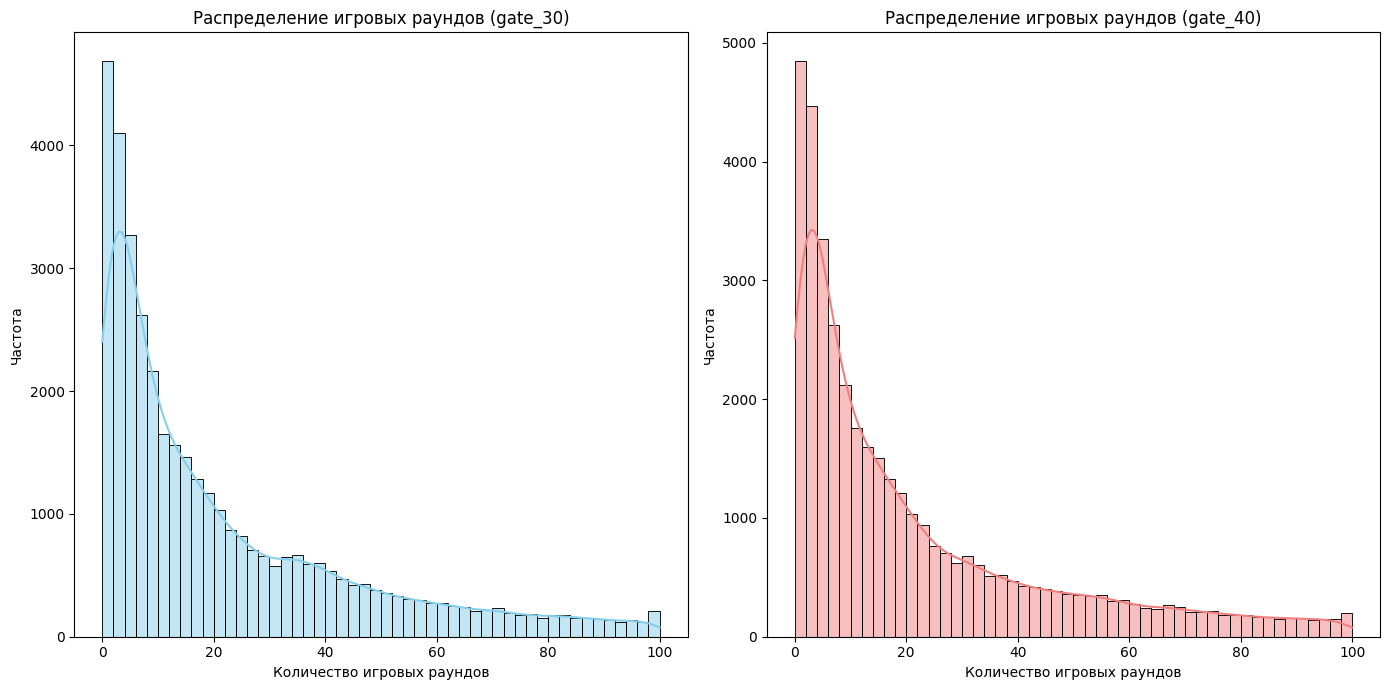

In [7]:
query = """
with filtereddata as (
    select 
        version,
        sum_gamerounds
    from cookie_cats.ab_results
    where sum_gamerounds <= 100
)
select 
    version,
    sum_gamerounds
from filtereddata
order by version, sum_gamerounds
"""

df_distribution = pd.read_sql(query, conn)

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
sns.histplot(data=df_distribution[df_distribution['version'] == 'gate_30'],
             x='sum_gamerounds',
             bins=50,
             kde=True, 
             color='skyblue')
plt.xlabel('Количество игровых раундов')
plt.ylabel('Частота')
plt.title('Распределение игровых раундов (gate_30)')

plt.subplot(1, 2, 2)
sns.histplot(data=df_distribution[df_distribution['version'] == 'gate_40'],
             x='sum_gamerounds',
             bins=50,
             kde=True,
             color='lightcoral')
plt.xlabel('Количество игровых раундов')
plt.ylabel('Частота')
plt.title('Распределение игровых раундов (gate_40)')

plt.tight_layout()
plt.show()

**Вывод:**  
Если смотреть на прохождение раундов по графикам, то видно, что распределение похоже на экспоненциальное, что закономерно. Единственное, что можно выделить, это небольшой провал в контрольной группе на уровне 30, видимо если игрок проходит 30 раунд, то он не останавливается на нём, а ещё играет.

In [8]:
query = """
select *
from cookie_cats.bootstrap_losevskiy_d_p(1000, 1000)
"""

df_result = pd.read_sql(query, conn)
display(df_result)

,metric_name,gate_30_mean,gate_40_mean,mean_difference,ci_lower,ci_upper,p_value,is_significant
0,mean_gamerounds,52.464881,51.232869,-1.232012,-12.188050,8.717825,0.938,False
1,median_gamerounds,16.831000,16.213000,-0.618000,-4.000000,2.000000,0.910,False
2,p75_gamerounds,50.421500,52.060500,1.639000,-8.250000,11.006250,0.800,False
3,p95_gamerounds,222.041200,218.501700,-3.539500,-62.952500,50.192500,0.932,False
4,retention_1,0.448430,0.442251,-0.006179,-0.050025,0.038000,0.812,False
5,retention_7,0.190582,0.181425,-0.009157,-0.044000,0.025000,0.586,False


**Итоговый вывод:**  
Проведя АБ тестирование мы увидели, что статистически значимых изменений не произошло, удержание 1 и 7 дня чуть уменьшилось, медиана и среднее также уменьшились,но эти уменьшения статистически не значимы.  
Скорее всего мы не увидели статистических изменений, так как время тестирования слишком маленькое, за 14 дней как минимум 50% пользователей дошло только до 16-17 раунда. За это время до 30 раунда дошло только 36-37% пользователей, а до 40 раунда около 30%. Требуется увеличить время тестирования как минимум в два раза.  
**Сформируем гипотезу:** Барьер 30 уровня перенесённый на 40 уровень не дал статистически значимого изменения, потому что был взят слишком короткий промежуток времени для тестирования (14 дней).  
**Рекомендации:**  
1. Провести повторный тест только с увеличенным временем тестирования, если трафик небольшой, то увеличить до 6 недель, чтобы существенно увеличить долю пользователей, доходящих до 30 и 40 уровня, пока изменение не вносить на всех пользователей, так как первый тест не показал статистически значимого изменения метрик.
2. Попробовать протестировать иные барьеры 25 уровень, 35 уровень, 45 уровень.
3. Попробовать, если есть возможность, сегментировать на возрастные когорты, страны, платящие/неплатящие пользователей, источник трафика, ОС/устройство. Возможно, эффект проявится только в отдельных сегментах.
4. Если будет проводится повторный тест с увеличенным временем, то можно добавить метрики удержания на 14 день, 21 день и 28 день.

Выполнил Лосевский Дмитрий